# Rapalog Discovery Pipeline
## 03 Unsupervised analysis notebook
### **Phase 3: Unsupervised Feature Clustering (without Similarity Score)**
A. Input data
B. Feature Extraction
C. Build feature dataframe
D. Run feature extraction
E. Apply feature scaling
F. PCA computation
G. PCA variance by component
H. K-Means evaluate and run functions
I. K-Means evaluation (10% sample)
  - Elbow and Silhouette score
  - Silhouette distribution
  - Feature correlation matrix
J. K-Means Clustering (chemistry features)
K. K-Means Visualization on PCA (chemistry features)
L. UMAP Clustering (chemistry features)
M. Cluster Interpretation (chemistry features)

In [1]:
# P3 Setup: imports, paths, and module wiring
import sys
import time
import pickle
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
config = importlib.reload(config)

import src.feature_engineering as feature_engineering
import src.dimensionality_reduction as dimensionality_reduction
import src.clustering as clustering

feature_engineering = importlib.reload(feature_engineering)
dimensionality_reduction = importlib.reload(dimensionality_reduction)
clustering = importlib.reload(clustering)

from src.feature_engineering import extract_features_safe, build_feature_df
from src.dimensionality_reduction import run_pca, plot_variance_explained, run_umap
from src.clustering import evaluate_k, run_kmeans

# Create results directory for notebook 03
results_dir = PROJECT_ROOT / "results" / "notebook_03"

results_dir.mkdir(parents=True, exist_ok=True)
print("Config module file:", config.__file__)

print("Results dir:", results_dir)
print("Project root:", PROJECT_ROOT)

Config module file: /Users/alangale/Projects/rapalog-discovery-pipeline/src/config.py
Results dir: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_03
Project root: /Users/alangale/Projects/rapalog-discovery-pipeline


In [2]:
# P3.A Input data
raw_dir = PROJECT_ROOT / "data" / "raw"
similarity_cache_path = raw_dir / config.SIMILARITY_SCORES_CACHE_FILE

if not similarity_cache_path.exists():
    raise FileNotFoundError(f"Missing similarity cache: {similarity_cache_path}")

with open(similarity_cache_path, "rb") as f:
    cached_scores = pickle.load(f)

results_df = cached_scores if isinstance(cached_scores, pd.DataFrame) else pd.DataFrame(cached_scores)
results_df = results_df.drop_duplicates(subset=["smiles"]).copy()
results_df["name"] = results_df["name"].fillna(results_df["coconut_id"])

results_ranked = (
    results_df.sort_values(by="sim_tv_frag", ascending=False)
    .reset_index(drop=True)
    .copy()
)
results_ranked["entry_n"] = np.arange(1, len(results_ranked) + 1)

df_ranked = results_ranked.copy()
target_col = "sim_r1_tv_frag"

print("Loaded rows:", len(results_df))
print("Ranked rows:", len(df_ranked))

Loaded rows: 96682
Ranked rows: 96682


In [3]:
# P3.B-P3.D Feature extraction and modeling table
# Benchmark extraction on 5K subset
start = time.time()
feat_5000 = build_feature_df(df_ranked.head(5000), target_col=target_col)
t_5000 = time.time() - start

print("Feature DF sizes:", feat_5000.shape)
if len(feat_5000) > 0:
    print(f"5000 molecules: {t_5000:.2f} sec")
    print(f"Per molecule: {t_5000/len(feat_5000):.4f} sec")
    print(f"Time for all molecules: {(t_5000 * len(df_ranked)/5000):.4f} sec")
else:
    print("ERROR: feature extraction failed")

# Full feature dataframe
feat_all = build_feature_df(df_ranked, target_col=target_col)

feature_cols = [
    "hbd",
    "hba",
    "rings",
    "aromatic_rings",
    "tpsa",
    "logp",
    "mw",
    "amide",
]

# One modeling table used by unsupervised clustering and regression
# Keep "name" and "smiles" for downstream use (docking), but exclude from X_features
model_df = feat_all[["name", "smiles"] + feature_cols + [target_col]].dropna().copy()

# Inputs/target split
X_features = model_df[feature_cols] # For K-Means and regression
y_target = model_df[target_col]     # For regression only

print("model_df shape:", model_df.shape)
print("X_features shape:", X_features.shape)
print("y_target shape:", y_target.shape)
model_df.head()         # Verify dataframe visually

Feature DF sizes: (5000, 11)
5000 molecules: 2.22 sec
Per molecule: 0.0004 sec
Time for all molecules: 42.9540 sec


[13:32:46] WARNING: not removing hydrogen atom without neighbors


model_df shape: (96682, 11)
X_features shape: (96682, 8)
y_target shape: (96682,)


,name,smiles,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide,sim_r1_tv_frag
0,CNP0124018.1,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,1,3,2,0,83.71,2.5554,379.545,3,0.784314
1,Fenestin A,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,2,4,3,0,105.80,2.7244,420.554,2,0.666667
2,Fenestin B,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,3,5,3,0,138.39,3.7055,519.687,2,0.666667
3,NCGC00398625-01,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,3,4,3,0,124.84,2.1380,477.650,5,0.666667
4,CNP0123277.2,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,2,4,4,0,92.34,3.9601,458.643,2,0.630631


PCA loadings:
                     PC1       PC2
hbd             0.409415 -0.091340
hba             0.462454 -0.197082
rings           0.036354  0.562111
aromatic_rings -0.039433  0.459741
tpsa            0.608767 -0.080177
logp           -0.085398  0.310601
mw              0.481188  0.345027
amide           0.078782  0.451155


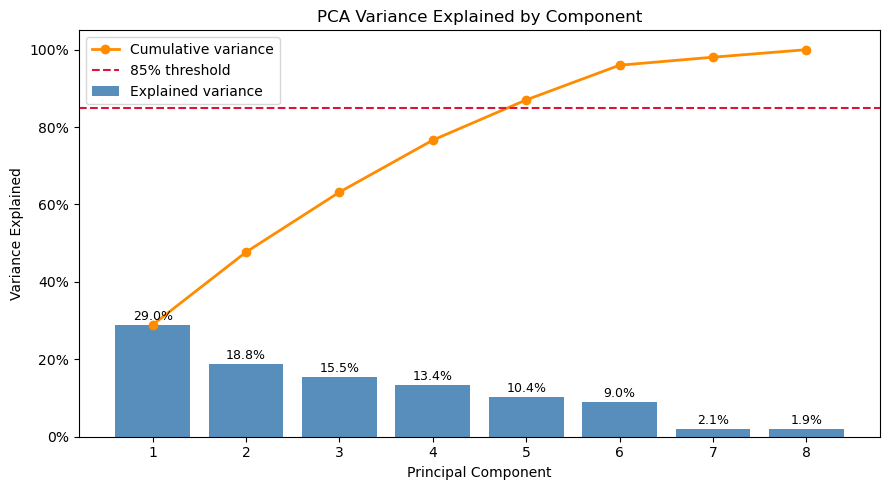

In [4]:
# P3.E-P3.G Scaling and dimensionality reduction

# Apply feature scaling
# Using all entries according to similarity (Tversky, feature-focused, radius=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)     # Scaled feature data

# PCA computation
pca_out = run_pca(
    X_scaled=X_scaled,
    model_df=model_df,
    feature_cols=feature_cols,
    n_components=2,
    random_state=config.RANDOM_STATE,
)

model_df = pca_out["model_df"]
X_pca = pca_out["X_pca"]
var_explained = pca_out["var_explained"]
loadings = pca_out["loadings"]

print("PCA loadings:")
print(loadings)

_ = plot_variance_explained(X_scaled)

Running K-Means diagnostics on 9,668 rows (10.0% sample) ...
Done.


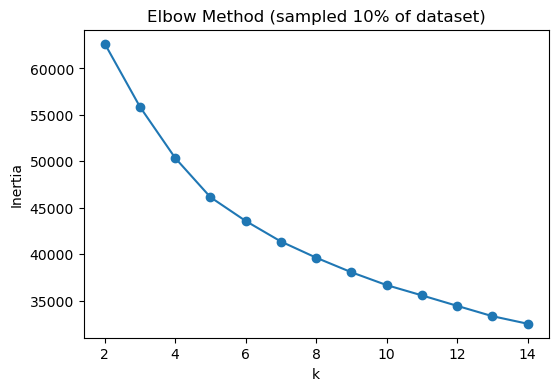

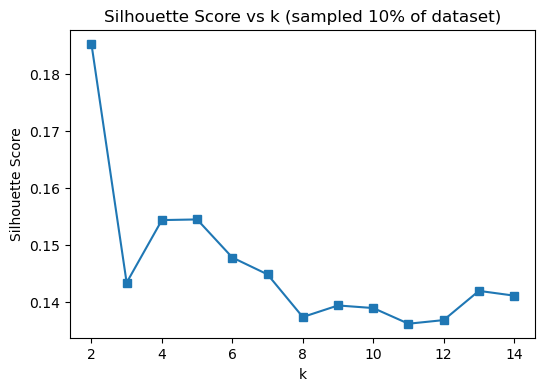

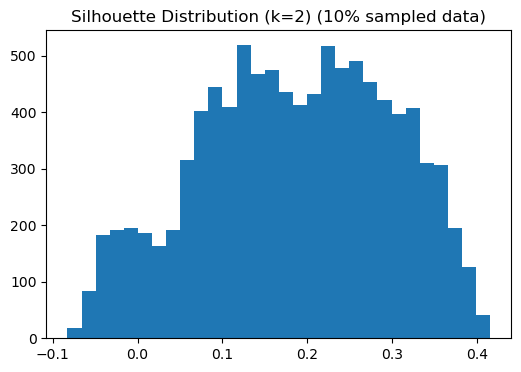

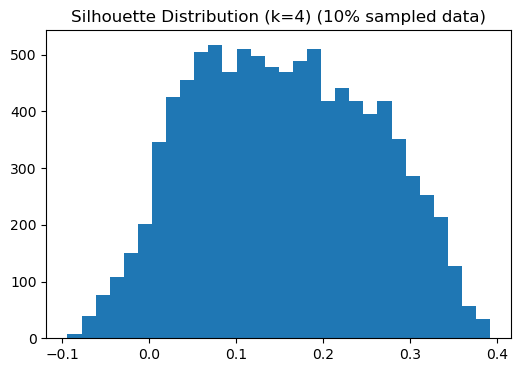

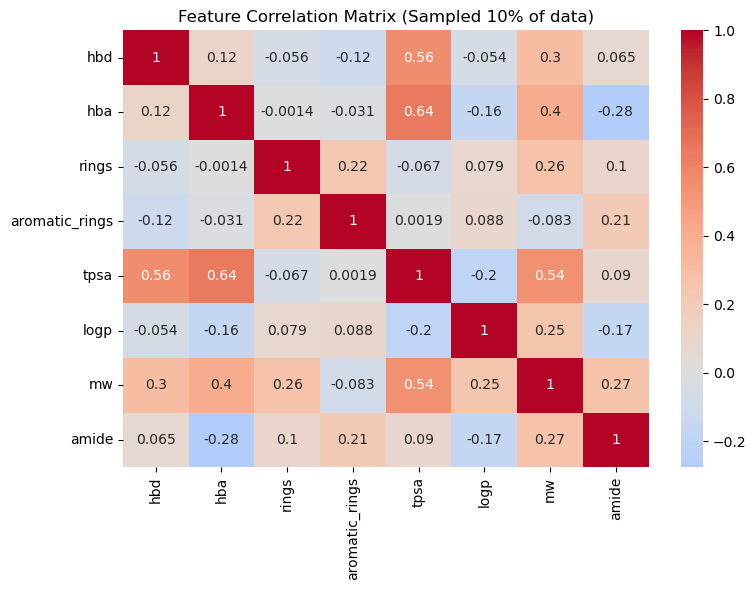

In [5]:
# P3.H-P3.I K-Means evaluation (10% sample)
k_range = range(2, 15)
sampled_frac = 0.10
n_eval = max(1000, int(len(X_scaled) * sampled_frac))
rng = np.random.default_rng(config.RANDOM_STATE)
eval_idx = rng.choice(len(X_scaled), size=n_eval, replace=False)
X_eval = X_scaled[eval_idx]

print(f"Running K-Means diagnostics on {n_eval:,} rows ({sampled_frac:.1%} sample) ...")
inertia, silhouette_scores = evaluate_k(X_eval, k_range)
print("Done.")

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (sampled 10% of dataset)")
plt.savefig(results_dir / "elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(k_range, silhouette_scores, marker="s")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k (sampled 10% of dataset)")
plt.savefig(results_dir / "silhouette_score_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()

labels_eval_k2 = run_kmeans(X_eval, 2, random_state=config.RANDOM_STATE)
labels_eval_k4 = run_kmeans(X_eval, 4, random_state=config.RANDOM_STATE)

sample_sil_k2 = silhouette_samples(X_eval, labels_eval_k2)
plt.figure(figsize=(6, 4))
plt.hist(sample_sil_k2, bins=30)
plt.title("Silhouette Distribution (k=2) (10% sampled data)")
plt.savefig(results_dir / "silhouette_distribution_k2.png", dpi=300, bbox_inches="tight")
plt.show()

sample_sil_k4 = silhouette_samples(X_eval, labels_eval_k4)
plt.figure(figsize=(6, 4))
plt.hist(sample_sil_k4, bins=30)
plt.title("Silhouette Distribution (k=4) (10% sampled data)")
plt.savefig(results_dir / "silhouette_distribution_k4.png", dpi=300, bbox_inches="tight")
plt.show()

corr_eval = feat_all.iloc[eval_idx][feature_cols]
corr_matrix = corr_eval.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (Sampled 10% of data)")
plt.tight_layout()
plt.savefig(results_dir / "feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

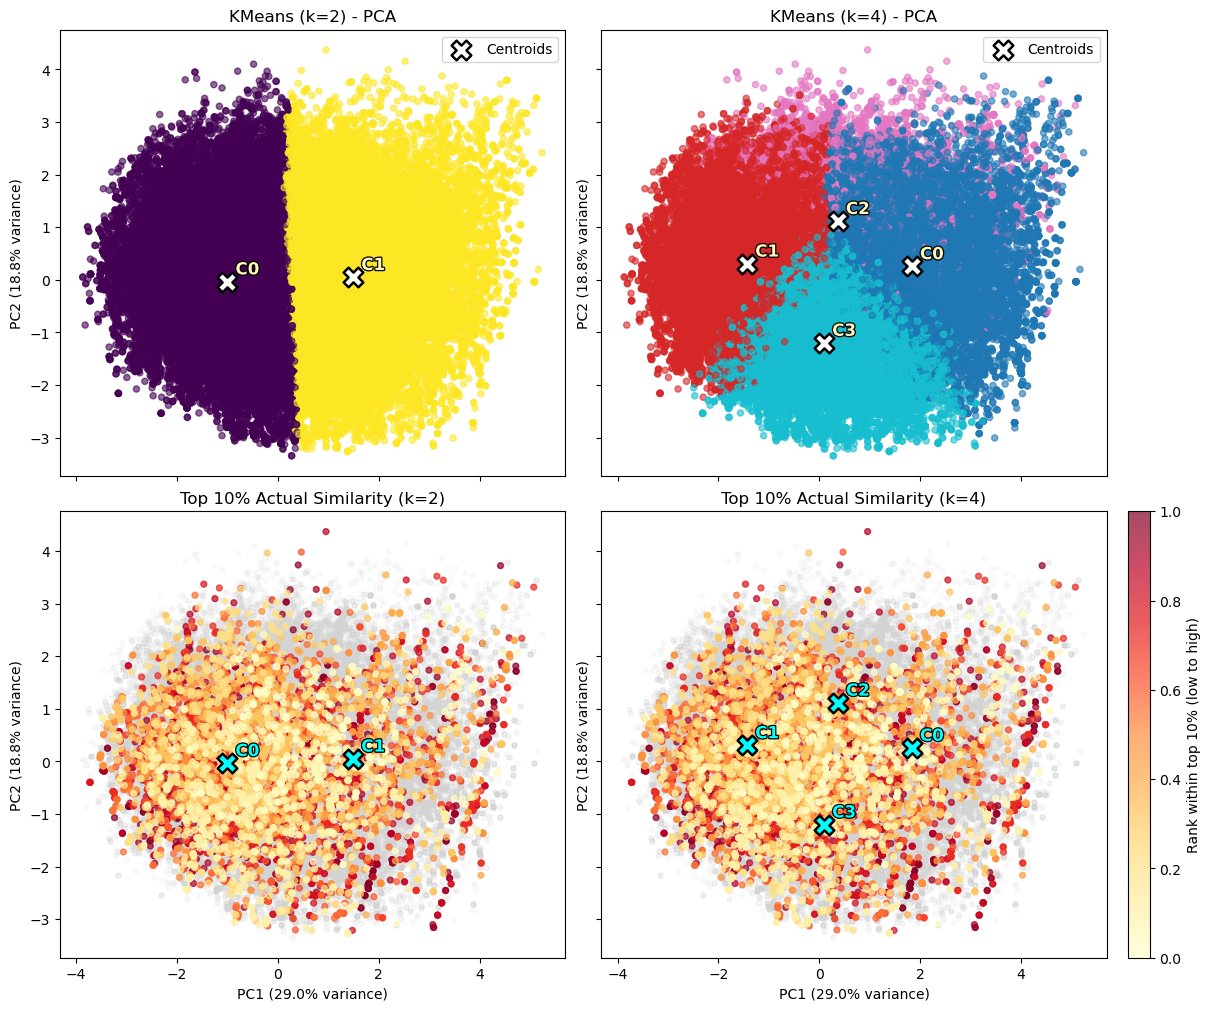

In [12]:
# P3.J-P3.K K-Means clustering and PCA visualization
# Clustering based only molecular features ("hbd", "hba", "rings", "aromatic_rings",
#    "tpsa", "logp", "mw", "amide")

# Run K-Means clustering for both k=2 and k=4 based on pharmokinetic features
labels_pharm_k2_kmeans = run_kmeans(X_scaled, 2, random_state=config.RANDOM_STATE)
labels_pharm_k4_kmeans = run_kmeans(X_scaled, 4, random_state=config.RANDOM_STATE)

plot_df = model_df.copy()
plot_df["cluster_k2"] = labels_pharm_k2_kmeans
plot_df["cluster_k4"] = labels_pharm_k4_kmeans

sim_col = "sim_r1_tv_frag"
if sim_col not in plot_df.columns:
    raise KeyError(f"Similarity column not found in plot dataframe: {sim_col}")

# Highlight highest similarity subset in bottom plot row
top_frac = 0.10
sim_cutoff = plot_df[sim_col].quantile(1 - top_frac)
top_df = plot_df.loc[plot_df[sim_col] >= sim_cutoff].copy()
top_df["top_rank_pct"] = top_df[sim_col].rank(pct=True)

centroids_k2 = plot_df.groupby("cluster_k2")[["PC1", "PC2"]].mean()
centroids_k4 = plot_df.groupby("cluster_k4")[["PC1", "PC2"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True)

# Top-left: k=2 clusters
axes[0, 0].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_k2"],
    alpha=0.60,
    cmap="viridis",
    s=20
)
axes[0, 0].scatter(
    centroids_k2["PC1"],
    centroids_k2["PC2"],
    c="white",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4,
    label="Centroids"
)
for cid, row in centroids_k2.iterrows():
    text = axes[0, 0].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="#fff7bc",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])

axes[0, 0].set_title("KMeans (k=2) - PCA")
axes[0, 0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")
axes[0, 0].legend(loc="best")

# Top-right: k=4 clusters
axes[0, 1].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_k4"],
    alpha=0.60,
    cmap="tab10",
    s=20
)
axes[0, 1].scatter(
    centroids_k4["PC1"],
    centroids_k4["PC2"],
    c="white",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4,
    label="Centroids"
)
for cid, row in centroids_k4.iterrows():
    text = axes[0, 1].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="#fff7bc",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])

axes[0, 1].set_title("KMeans (k=4) - PCA")
axes[0, 1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")
axes[0, 1].legend(loc="best")

# Bottom-left: top similarity overlay on k=2 view
axes[1, 0].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c="lightgray",
    alpha=0.10,
    s=12
)
sc_top = axes[1, 0].scatter(
    top_df["PC1"],
    top_df["PC2"],
    c=top_df["top_rank_pct"],
    cmap="YlOrRd",
    alpha=0.70,
    s=18,
    vmin=0.0,
    vmax=1.0
)
axes[1, 0].scatter(
    centroids_k2["PC1"],
    centroids_k2["PC2"],
    c="cyan",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4
)
for cid, row in centroids_k2.iterrows():
    text = axes[1, 0].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        #color="#fff7bc",
        c="cyan",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])

axes[1, 0].set_title(f"Top {int(top_frac*100)}% Actual Similarity (k=2)")
axes[1, 0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)")
axes[1, 0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")

# Bottom-right: top similarity overlay on k=4 view
axes[1, 1].scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c="lightgray",
    alpha=0.10,
    s=12
)
axes[1, 1].scatter(
    top_df["PC1"],
    top_df["PC2"],
    c=top_df["top_rank_pct"],
    cmap="YlOrRd",
    alpha=0.70,
    s=18,
    vmin=0.0,
    vmax=1.0
)
axes[1, 1].scatter(
    centroids_k4["PC1"],
    centroids_k4["PC2"],
    c="cyan",
    s=200,
    marker="X",
    edgecolors="black",
    linewidths=1.8,
    zorder=4
)
for cid, row in centroids_k4.iterrows():
    text = axes[1, 1].annotate(
        f"C{cid}",
        xy=(row["PC1"], row["PC2"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        #color="#fff7bc",
        c="cyan",
        ha="left",
        va="bottom",
        zorder=5
    )
    text.set_path_effects([pe.Stroke(linewidth=1.8, foreground="black"), pe.Normal()])

axes[1, 1].set_title(f"Top {int(top_frac*100)}% Actual Similarity (k=4)")
axes[1, 1].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)")
axes[1, 1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")

cbar = fig.colorbar(sc_top, ax=axes[1, :], fraction=0.03, pad=0.02)
cbar.set_label(f"Rank within top {int(top_frac*100)}% (low to high)")

plt.savefig(results_dir / "kmeans_pca_clusters_k2_k4.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/alangale/miniconda3/envs/tfmac/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


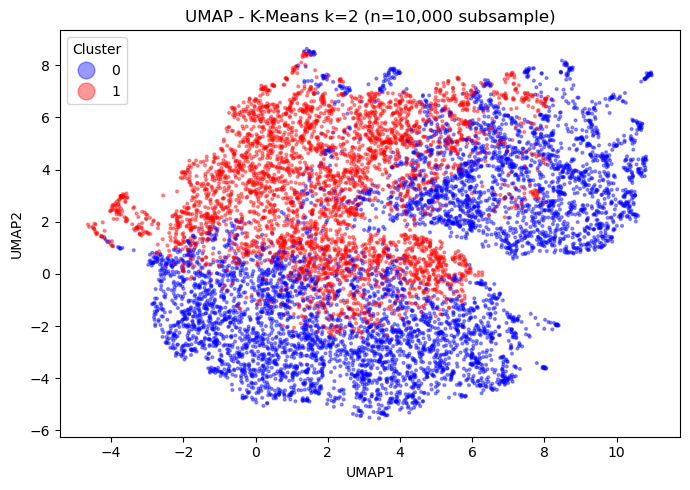

In [13]:
# P3.L UMAP clustering (k=2 labels, sampled)
umap_out = run_umap(
    X_scaled=X_scaled,
    labels=labels_pharm_k2_kmeans,
    sample_size=10000,
    n_neighbors=50,
    min_dist=0.5,
    random_state=config.RANDOM_STATE,
)

X_umap = umap_out["embedding"]
labels_umap = umap_out["labels"]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_umap, cmap="bwr", s=4, alpha=0.4)
ax.legend(*sc.legend_elements(), title="Cluster", markerscale=2)
ax.set_title("UMAP - K-Means k=2 (n=10,000 subsample)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.savefig(results_dir / "umap_kmeans_k2.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# P3.M Cluster interpretation
print("PCA feature loadings (PC1 and PC2)")
display(loadings.round(3))
loadings.round(3).to_csv(results_dir / "pca_loadings.csv")

means_k2_original = plot_df.groupby("cluster_k2")[feature_cols].mean().round(3)
means_k4_original = plot_df.groupby("cluster_k4")[feature_cols].mean().round(3)

print("Feature means (k=2 clusters)")
display(means_k2_original)
means_k2_original.to_csv(results_dir / "kmeans_k2_cluster_means.csv")

means_k4_original.to_csv(results_dir / "kmeans_k4_cluster_means.csv")

print("Feature means (k=4 clusters)")
display(means_k4_original)

PCA feature loadings (PC1 and PC2)


,PC1,PC2
hbd,0.409,-0.091
hba,0.462,-0.197
rings,0.036,0.562
aromatic_rings,-0.039,0.460
tpsa,0.609,-0.080
logp,-0.085,0.311
mw,0.481,0.345
amide,0.079,0.451


Feature means (k=2 clusters)


,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide
cluster_k2,,,,,,,,
0,1.557,4.860,3.710,1.852,78.481,3.523,399.431,0.751
1,2.570,6.417,3.868,1.749,111.224,3.445,469.332,0.905


Feature means (k=4 clusters)


,hbd,hba,rings,aromatic_rings,tpsa,logp,mw,amide
cluster_k4,,,,,,,,
0,2.643,6.731,4.130,1.711,113.901,3.860,491.365,0.523
1,1.394,4.557,3.915,2.001,70.748,3.943,400.508,0.545
2,2.202,4.766,4.058,2.120,96.121,3.127,451.732,2.532
3,1.982,6.055,3.173,1.481,96.716,2.896,396.835,0.345
